In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='fare'>

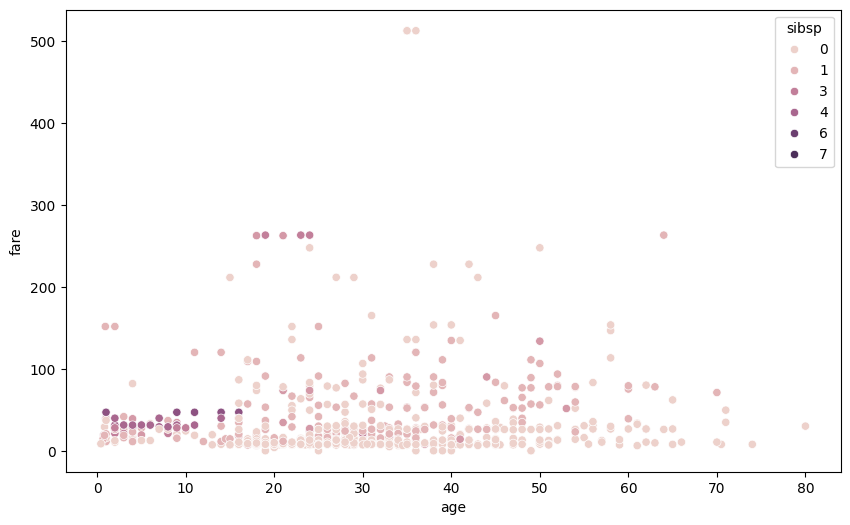

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=titanic, x='age', y='fare', hue='sibsp')

<Axes: xlabel='age', ylabel='Count'>

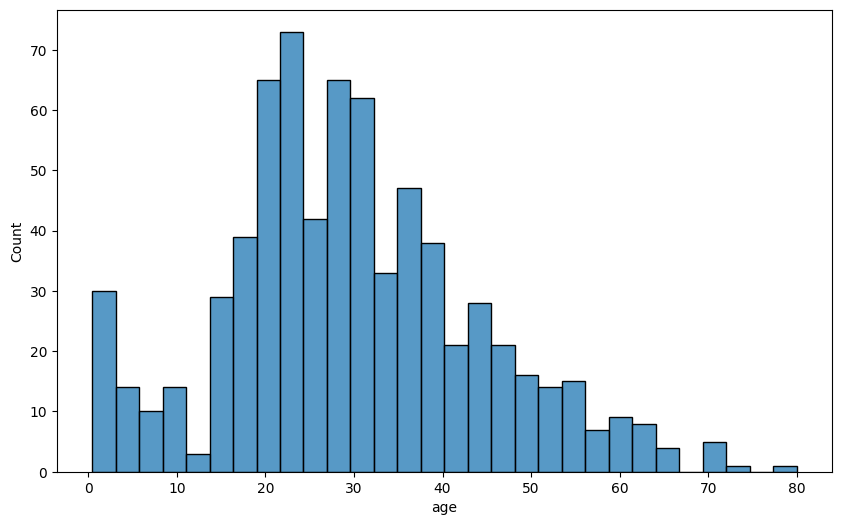

In [23]:
# for histogram
plt.figure(figsize=(10,6))
sns.histplot(data=titanic, x='age', bins=30)

<Axes: xlabel='age', ylabel='Density'>

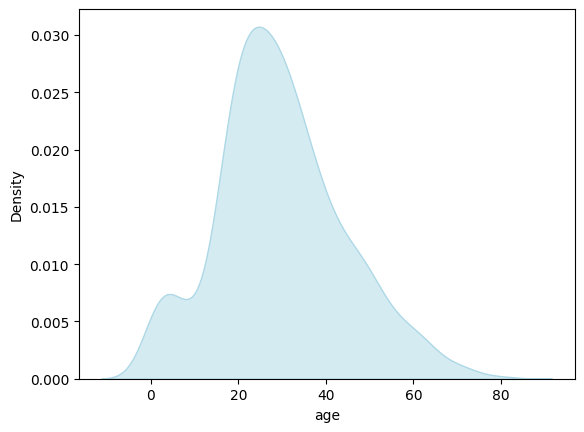

In [24]:
#KDEPlot
sns.kdeplot(data=titanic, x='age', fill=True, alpha=0.5, color="lightblue")

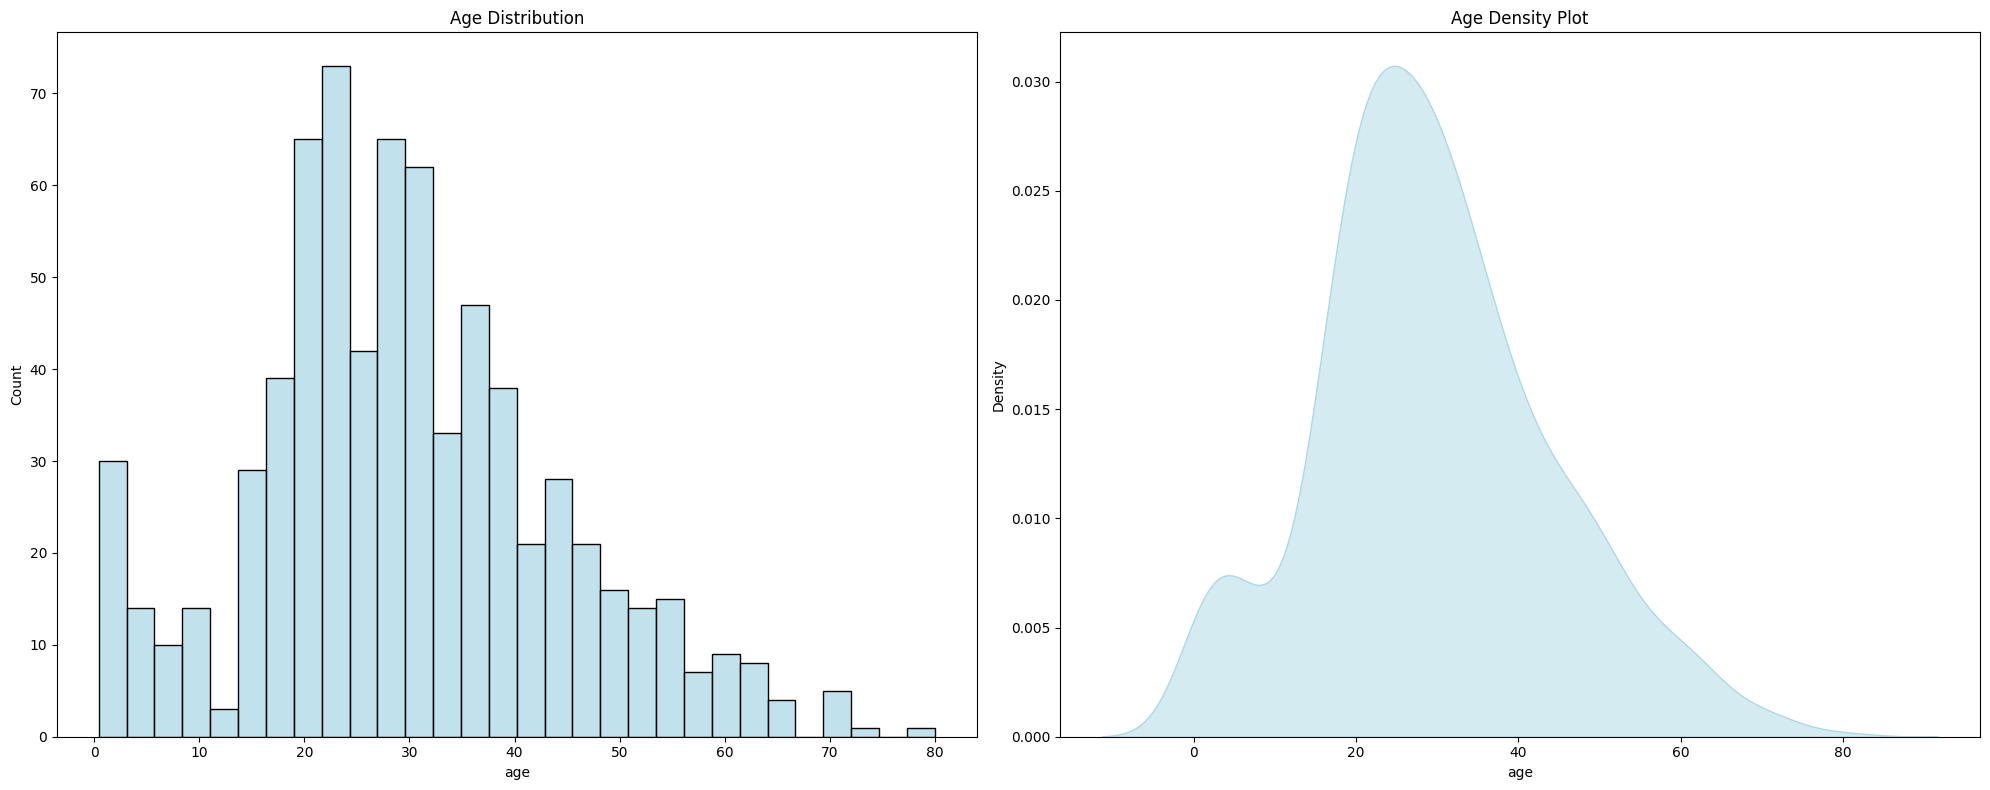

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,8))
sns.histplot(data=titanic, x='age', bins=30, ax=ax1, color='lightblue')
ax1.set_title('Age Distribution')
sns.kdeplot(data=titanic, x='age', fill=True, alpha=0.5, color="lightblue", ax=ax2)
ax2.set_title('Age Density Plot')
fig.tight_layout()

Lower Bound: -6.6875, Upper Bound: 64.8125


Text(0.5, 1.0, 'age after removing outliers')

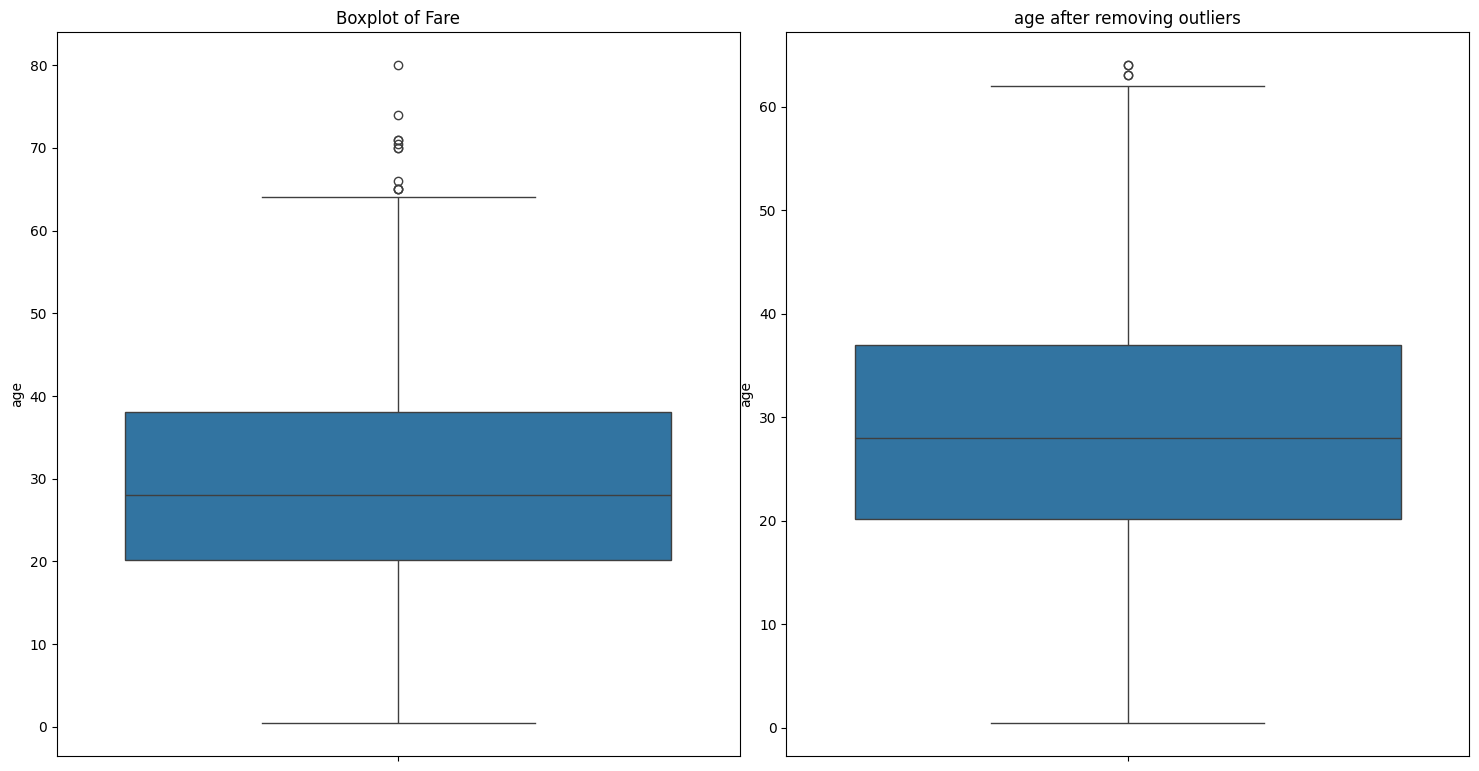

In [26]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15, 8))
sns.boxplot(data=titanic, y="age", ax=ax1)
ax1.set_title("before outlier")
ax1.set_title('Boxplot of Fare')
plt.tight_layout()
#calculation of IQR
Q1 = titanic['age'].quantile(0.25)
Q3 = titanic['age'].quantile(0.75)
Q2 = titanic['age'].median()
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")



# now replacing the outliers
# for i in range(0, len([titanic["age"]])+1):      
#     if (titanic["age"][i]> upper_bound):
#         titanic["age"][i] = Q2
#     elif(titanic["age"][i]< lower_bound):
#         titanic["age"][i] = Q2

mask = (titanic["age"] > upper_bound) | (titanic["age"] < lower_bound)
titanic.loc[mask, "age"] = Q2
#printing after removing outliers

sns.boxplot(data=titanic, y = "age", ax=ax2)
ax2.set_title("age after removing outliers")

# fig.suptitle("comparision")


Text(0.5, 1.0, 'Correlation Heatmap')

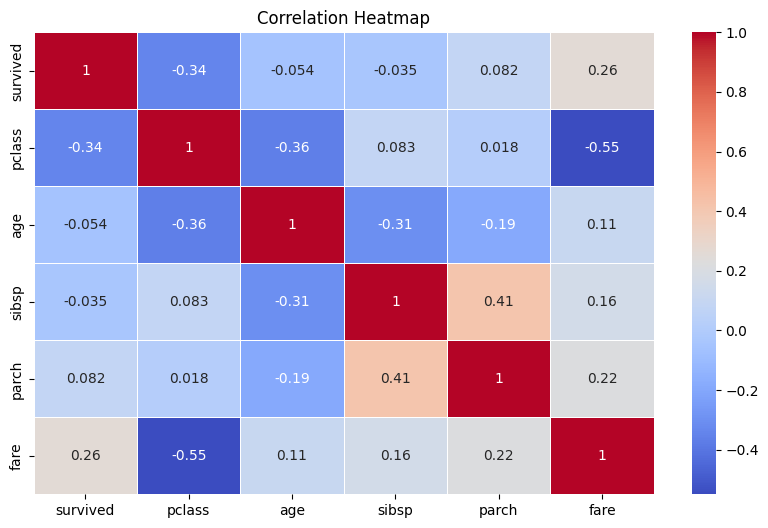

In [27]:
# heatmap
numerical_col = titanic.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,6))
correlation_matrix = titanic[numerical_col].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'Correlation Heatmap with Mask')

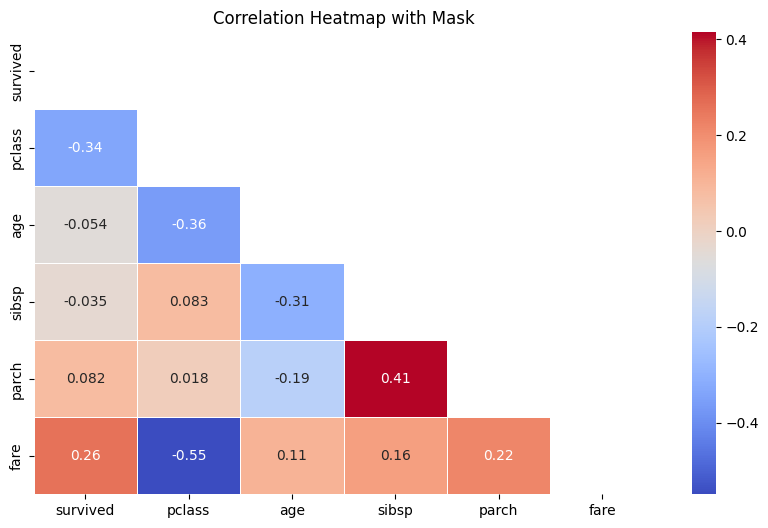

In [28]:
#creating mask 
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap with Mask')

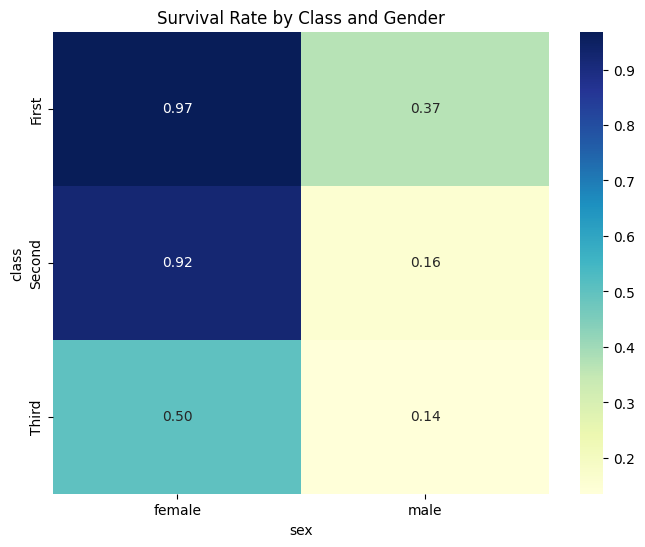

In [29]:
# Categorical Heatmap for survival rate by class and gender

survival_pivot = titanic.pivot_table(index='class', columns='sex', values='survived', aggfunc='mean')
# survival_pivot


plt.figure(figsize=(8, 6))
sns.heatmap(survival_pivot, annot=True, fmt=".2f", cmap='YlGnBu', cbar=True)
plt.title('Survival Rate by Class and Gender');

<Axes: xlabel='embark_town', ylabel='class'>

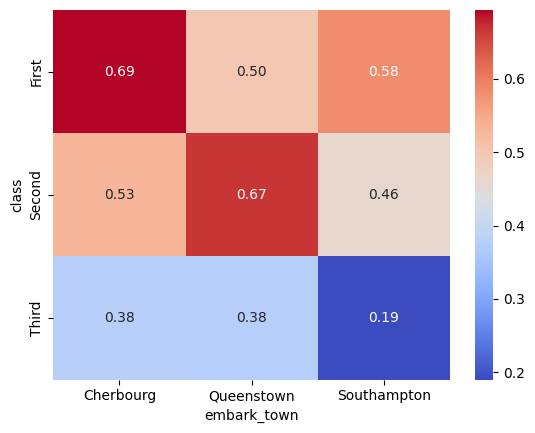

In [30]:
# creating pivot table using class and embarktown
# titanic.head()
pivot_table = titanic.pivot_table(index="class", columns="embark_town", values="survived", aggfunc="mean")
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

<Figure size 1000x600 with 0 Axes>

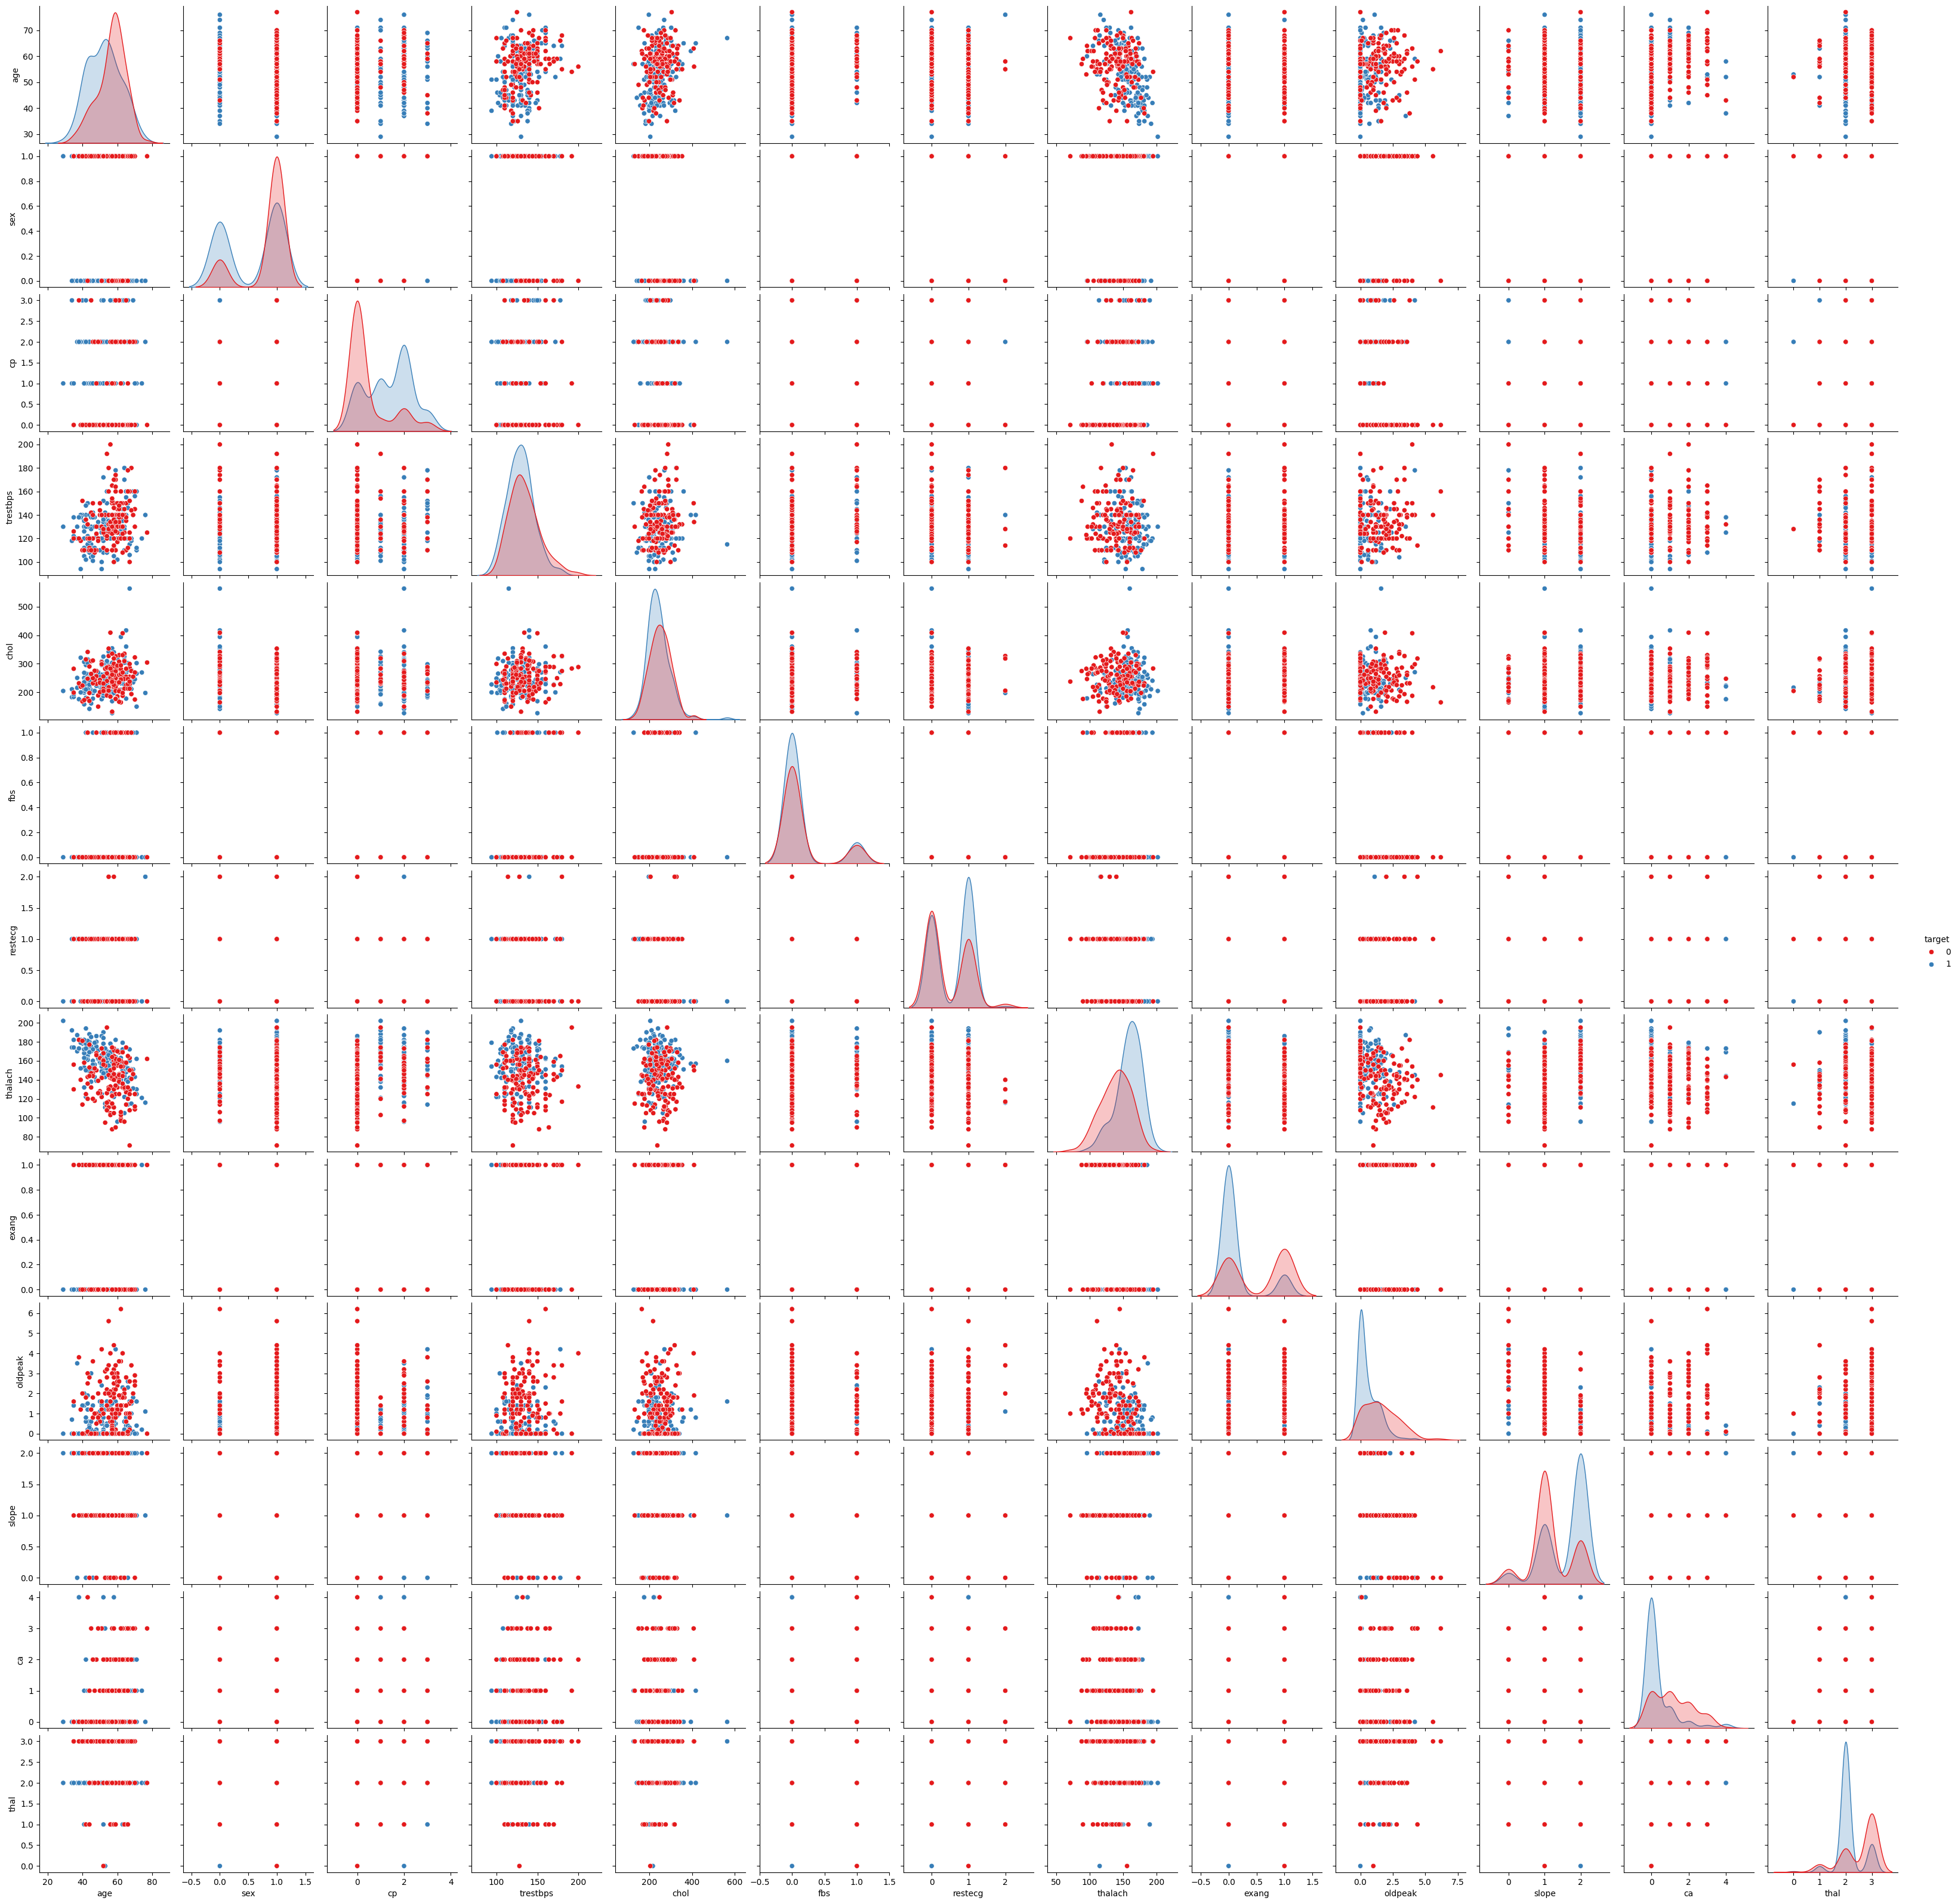

In [ ]:
heart_disease = pd.read_csv("./data/heart-disease.csv")
numerical_col = heart_disease.select_dtypes(include=np.number).columns
numerical_col = numerical_col.drop("target")

plt.figure(figsize=(10,6))
sns.pairplot(heart_disease, vars=numerical_col, hue="target", palette="Set1");